<a href="https://colab.research.google.com/github/Bijayaaaa/AI_Internship/blob/object_detection/Object_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install pycocotools pillow matplotlib tqdm


Looking in indexes: https://download.pytorch.org/whl/cu118


In [ ]:
import zipfile
zip_path = "/content/My First Project.v1-car_detection.coco.zip"  # ← change path if local PC
extract_to = "/content/dataset"  # location to extract

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Dataset Extracted")


✅ Dataset Extracted


In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
 #Define transformations
class CocoTransform:
    def __call__(self, image, target):
        image = F.to_tensor(image)  # Convert PIL image to tensor
        return image, target

In [ ]:
# Dataset class
def get_coco_dataset(img_dir, ann_file):
    return CocoDetection(
        root=img_dir,
        annFile=ann_file,
        transforms=CocoTransform()
    )

# Load datasets
train_dataset = get_coco_dataset(
    img_dir="/content/dataset/train",
    ann_file="/content/dataset/train/_annotations.coco.json"
)


val_dataset = get_coco_dataset(
    img_dir="/content/dataset/valid",
    ann_file="/content/dataset/valid/_annotations.coco.json"
)



# DataLoader
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [ ]:
# Load Faster R-CNN with ResNet-50 backbone
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [ ]:
# Initialize the model
num_classes = 2
model = get_model(num_classes)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 163MB/s]


In [ ]:
# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Define optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [ ]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    for images, targets in data_loader:
        # Move images to the device
        images = [img.to(device) for img in images]

        # Validate and process targets
        processed_targets = []
        valid_images = []
        for i, target in enumerate(targets):
            boxes = []
            labels = []
            for obj in target:
                # Extract bbox
                bbox = obj["bbox"]  # Format: [x, y, width, height]
                x, y, w, h = bbox

                # Ensure the width and height are positive
                if w > 0 and h > 0:
                    boxes.append([x, y, x + w, y + h])  # Convert to [x_min, y_min, x_max, y_max]
                    labels.append(obj["category_id"])

            # Only process if there are valid boxes
            if boxes:
                processed_target = {
                    "boxes": torch.tensor(boxes, dtype=torch.float32).to(device),
                    "labels": torch.tensor(labels, dtype=torch.int64).to(device),
                }
                processed_targets.append(processed_target)
                valid_images.append(images[i])  # Add only valid images

        # Skip iteration if no valid targets
        if not processed_targets:
            continue

        # Ensure images and targets are aligned
        images = valid_images

        # Forward pass
        loss_dict = model(images, processed_targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backpropagation
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    print(f"Epoch [{epoch}] Loss: {losses.item():.4f}")

In [ ]:
# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, train_loader, device, epoch)
    lr_scheduler.step()

    # Save the model's state dictionary after every epoch
    model_path = f"car_detection_model_{epoch + 1}.pth"
    torch.save(model.state_dict(), model_path)
    print(f"Model saved: {model_path}")

Epoch [0] Loss: 0.4669
Model saved: car_detection_model_1.pth
Epoch [1] Loss: 0.0390
Model saved: car_detection_model_2.pth
Epoch [2] Loss: 0.0901
Model saved: car_detection_model_3.pth
Epoch [3] Loss: 0.0253
Model saved: car_detection_model_4.pth
Epoch [4] Loss: 0.1170
Model saved: car_detection_model_5.pth


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 11.14it/s]


✅ Predictions saved to: predictions.json
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.02s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.670
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.980
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.844
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.400
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.657
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.825
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.503
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.727
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.727
 Average Recall     (AR) @[

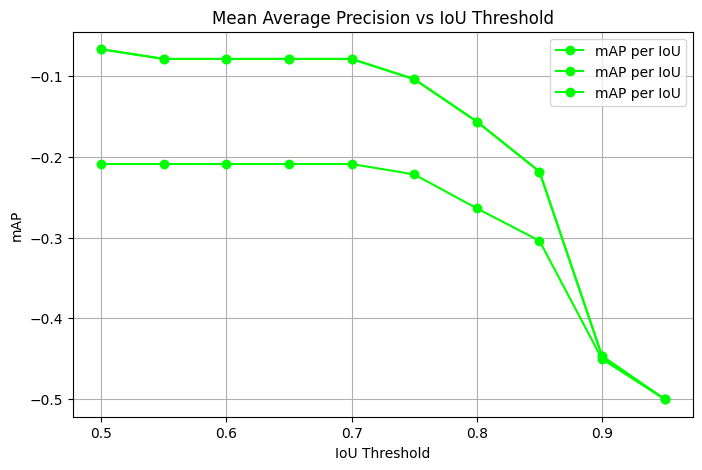

In [ ]:
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pycocotools.cocoeval import COCOeval


#  Convert model predictions to COCO JSON format
def get_coco_predictions(model, dataset, device, output_json="predictions.json"):
    model.eval()
    coco_results = []

    for img_idx in tqdm(range(len(dataset)), desc="Evaluating"):
        img, target = dataset[img_idx]

        # Extract image_id safely
        if isinstance(target, list) and len(target) > 0 and "image_id" in target[0]:
            image_id = int(target[0]["image_id"])
        elif isinstance(target, dict) and "image_id" in target:
            image_id = int(target["image_id"])
        else:
            image_id = img_idx  # fallback

        with torch.no_grad():
            prediction = model([img.to(device)])[0]

        boxes = prediction["boxes"].cpu().numpy()
        scores = prediction["scores"].cpu().numpy()
        labels = prediction["labels"].cpu().numpy()

        for box, score, label in zip(boxes, scores, labels):
            x_min, y_min, x_max, y_max = box
            coco_box = [
                float(x_min),
                float(y_min),
                float(x_max - x_min),
                float(y_max - y_min)
            ]

            coco_results.append({
                "image_id": image_id,
                "category_id": int(label),
                "bbox": coco_box,
                "score": float(score)
            })

    # Save to JSON file
    with open(output_json, "w") as f:
        json.dump(coco_results, f)

    print(f"✅ Predictions saved to: {output_json}")
    return output_json


#  Evaluate using COCO metrics and visualize results
def evaluate_coco_metrics(model, dataset, ann_file, device):
    results_json = get_coco_predictions(model, dataset, device)

    # Load GT and predictions
    coco_gt = dataset.coco
    coco_dt = coco_gt.loadRes(results_json)

    coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    print("\n📊 COCO Evaluation Summary:")
    print(f"mAP (IoU=0.50:0.95): {coco_eval.stats[0]:.4f}")
    print(f"AP (IoU=0.50): {coco_eval.stats[1]:.4f}")
    print(f"AR (maxDets=100): {coco_eval.stats[8]:.4f}")

    # 🔹 Extract data for plotting
    precisions = coco_eval.eval['precision']  # [TxRxKxAxM]
    iou_thresholds = coco_eval.params.iouThrs
    mean_precisions = np.mean(precisions, axis=(1, 2, 3))  # Average over recall, category, area

    # 🔹 Plot mAP vs IoU threshold
    plt.figure(figsize=(8, 5))
    plt.plot(iou_thresholds, mean_precisions, marker='o', color='lime', label='mAP per IoU')
    plt.title("Mean Average Precision vs IoU Threshold")
    plt.xlabel("IoU Threshold")
    plt.ylabel("mAP")
    plt.grid(True)
    plt.legend()
    plt.show()


#  Example usage
ann_file = "/content/dataset/valid/_annotations.coco.json"  # Your validation annotations
evaluate_coco_metrics(model, val_dataset, ann_file, device)


✅ Loaded model from: /content/car_detection_model_5.pth
💾 Saved prediction image to: /content/car-6810885_1280_pred.jpg


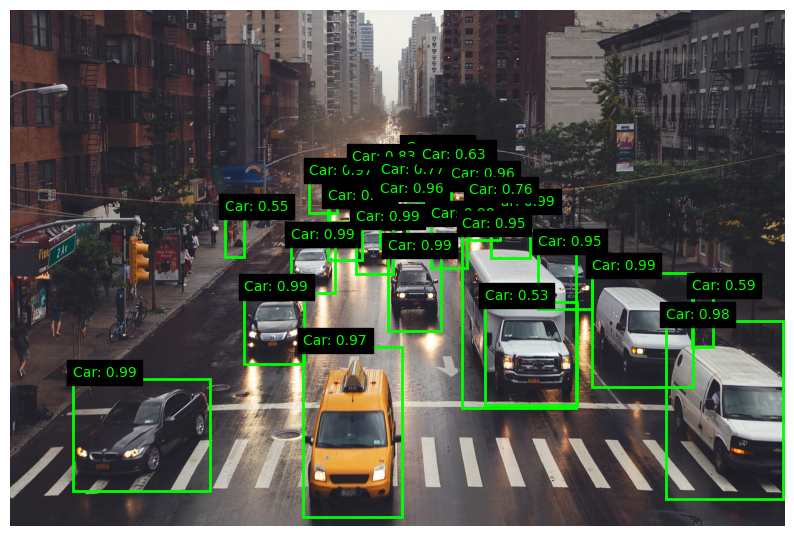

In [ ]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

# -------------------------------
# 1️⃣ Load the trained model
# -------------------------------
def load_model(model_path, num_classes, device):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    print(f"✅ Loaded model from: {model_path}")
    return model


# -------------------------------
# 2️⃣ Define image transformation
# -------------------------------
transform = transforms.Compose([
    transforms.ToTensor()
])


# -------------------------------
# 3️⃣ Inference function
# -------------------------------
def predict_image(model, image_path, device, threshold=0.5, save_output=False):
    image = Image.open(image_path).convert("RGB")
    img_tensor = transform(image).to(device)

    with torch.no_grad():
        predictions = model([img_tensor])[0]

    boxes = predictions["boxes"].cpu()
    scores = predictions["scores"].cpu()

    fig, ax = plt.subplots(1, figsize=(10, 7))
    ax.imshow(image)
    ax.axis("off")

    for box, score in zip(boxes, scores):
        if score > threshold:
            x1, y1, x2, y2 = box
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, f"Car: {score:.2f}", color='lime',
                    fontsize=10, backgroundcolor='black')

    if save_output:
        out_path = f"{os.path.splitext(image_path)[0]}_pred.jpg"
        plt.savefig(out_path, bbox_inches='tight')
        print(f"💾 Saved prediction image to: {out_path}")

    plt.show()


# -------------------------------
# 4️⃣ Run inference
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 2  # 1 (car) + 1 (background)
model_path = "/content/car_detection_model_5.pth"

model = load_model(model_path, num_classes, device)

# Test on a single image
image_path = "/content/car-6810885_1280.jpg"  # change path here
predict_image(model, image_path, device, threshold=0.5, save_output=True)
